# Commodity Prices Dataset Analysis

Kaggle Dataset Link: https://www.kaggle.com/datasets/debashish311601/commodity-prices

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('commodity_futures.csv')

In [3]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [4]:
df.shape

(6092, 24)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6092 entries, 0 to 6091
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6092 non-null   str    
 1   NATURAL GAS          6083 non-null   float64
 2   GOLD                 6082 non-null   float64
 3   WTI CRUDE            6083 non-null   float64
 4   BRENT CRUDE          6090 non-null   float64
 5   SOYBEANS             6083 non-null   float64
 6   CORN                 6084 non-null   float64
 7   COPPER               6083 non-null   float64
 8   SILVER               6079 non-null   float64
 9   LOW SULPHUR GAS OIL  6090 non-null   float64
 10  LIVE CATTLE          6084 non-null   float64
 11  SOYBEAN OIL          6079 non-null   float64
 12  ALUMINIUM            6045 non-null   float64
 13  SOYBEAN MEAL         6082 non-null   float64
 14  ZINC                 6046 non-null   float64
 15  ULS DIESEL           6083 non-null   float64
 16 

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [7]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [8]:
# Create year and month columns for seasonal/group analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [9]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,Year,Month
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07,2000,1
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73,2000,1
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56,2000,1
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08,2000,1
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96,2000,1


In [10]:
# Quick check for missing values
print(df.isnull().sum())

Date                      0
NATURAL GAS               9
GOLD                     10
WTI CRUDE                 9
BRENT CRUDE               2
SOYBEANS                  9
CORN                      8
COPPER                    9
SILVER                   13
LOW SULPHUR GAS OIL       2
LIVE CATTLE               8
SOYBEAN OIL              13
ALUMINIUM                47
SOYBEAN MEAL             10
ZINC                     46
ULS DIESEL                9
NICKEL                   46
WHEAT                    14
SUGAR                     9
GASOLINE               1491
COFFEE                   12
LEAN HOGS                 8
HRW WHEAT                14
COTTON                   13
Year                      0
Month                     0
dtype: int64


In [11]:
# Forward fill missing values (if any)
df_ffill = df.ffill()

In [12]:
df_ffill.isnull().sum()

Date                      0
NATURAL GAS               1
GOLD                      1
WTI CRUDE                 1
BRENT CRUDE               1
SOYBEANS                  0
CORN                      0
COPPER                    1
SILVER                    1
LOW SULPHUR GAS OIL       1
LIVE CATTLE               0
SOYBEAN OIL               0
ALUMINIUM                 1
SOYBEAN MEAL              0
ZINC                      0
ULS DIESEL                1
NICKEL                    0
WHEAT                     0
SUGAR                     0
GASOLINE               1483
COFFEE                    0
LEAN HOGS                 0
HRW WHEAT                 0
COTTON                    0
Year                      0
Month                     0
dtype: int64

In [13]:
df_clean = df.ffill().bfill()

In [14]:
df_clean.isnull().sum()

Date                   0
NATURAL GAS            0
GOLD                   0
WTI CRUDE              0
BRENT CRUDE            0
SOYBEANS               0
CORN                   0
COPPER                 0
SILVER                 0
LOW SULPHUR GAS OIL    0
LIVE CATTLE            0
SOYBEAN OIL            0
ALUMINIUM              0
SOYBEAN MEAL           0
ZINC                   0
ULS DIESEL             0
NICKEL                 0
WHEAT                  0
SUGAR                  0
GASOLINE               0
COFFEE                 0
LEAN HOGS              0
HRW WHEAT              0
COTTON                 0
Year                   0
Month                  0
dtype: int64

In [15]:
# Price trends of Commodities (Descriptive)
# Metals

In [16]:
df_clean.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,Year,Month
0,2000-01-03,2.176,283.7,25.55,24.39,456.50,200.75,0.8480,5.375,213.50,...,8446.0,247.50,6.10,188.88,116.50,55.975,274.25,51.07,2000,1
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,8314.0,247.25,5.77,188.88,116.25,55.625,274.00,50.73,2000,1
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,8307.0,249.75,5.81,188.88,118.60,55.075,276.25,51.56,2000,1
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,8252.0,248.50,5.77,188.88,116.85,55.175,275.00,52.08,2000,1
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,8174.0,251.75,5.84,188.88,114.15,55.625,277.75,53.96,2000,1


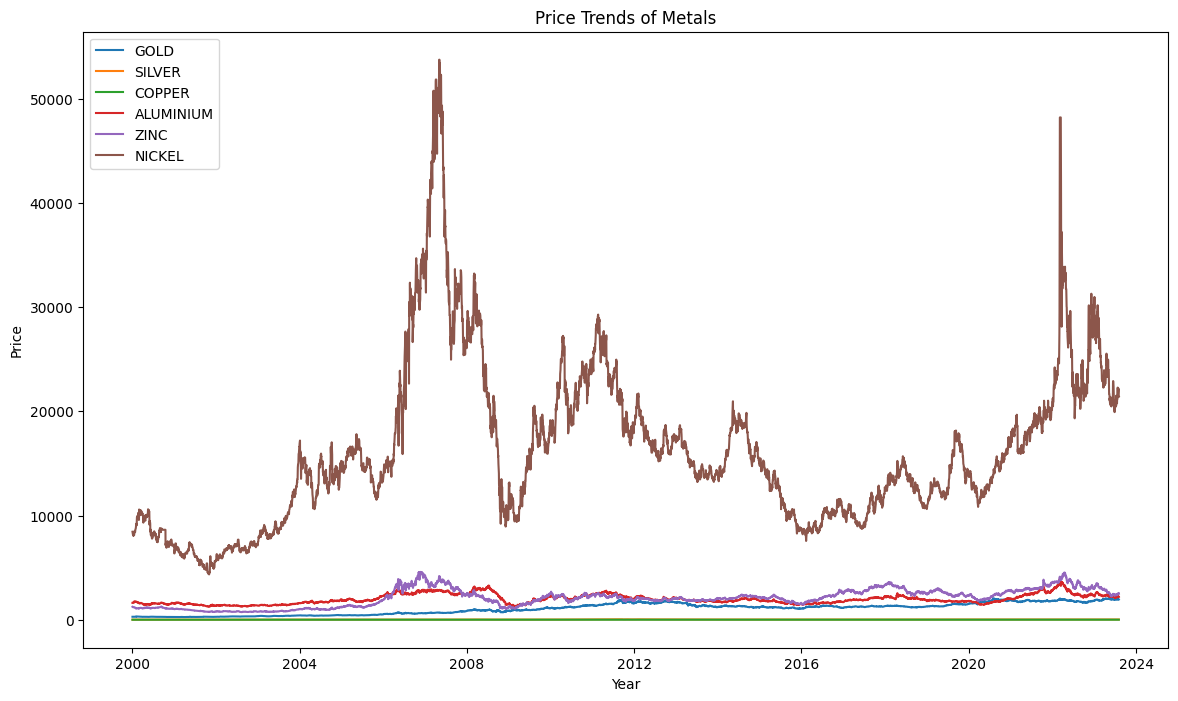

In [17]:
metals = ["GOLD", "SILVER", "COPPER", "ALUMINIUM", "ZINC", "NICKEL"]
plt.figure(figsize=(14, 8))
for col in metals:
    plt.plot(df_clean['Date'], df_clean[col], label=col)
plt.title("Price Trends of Metals")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

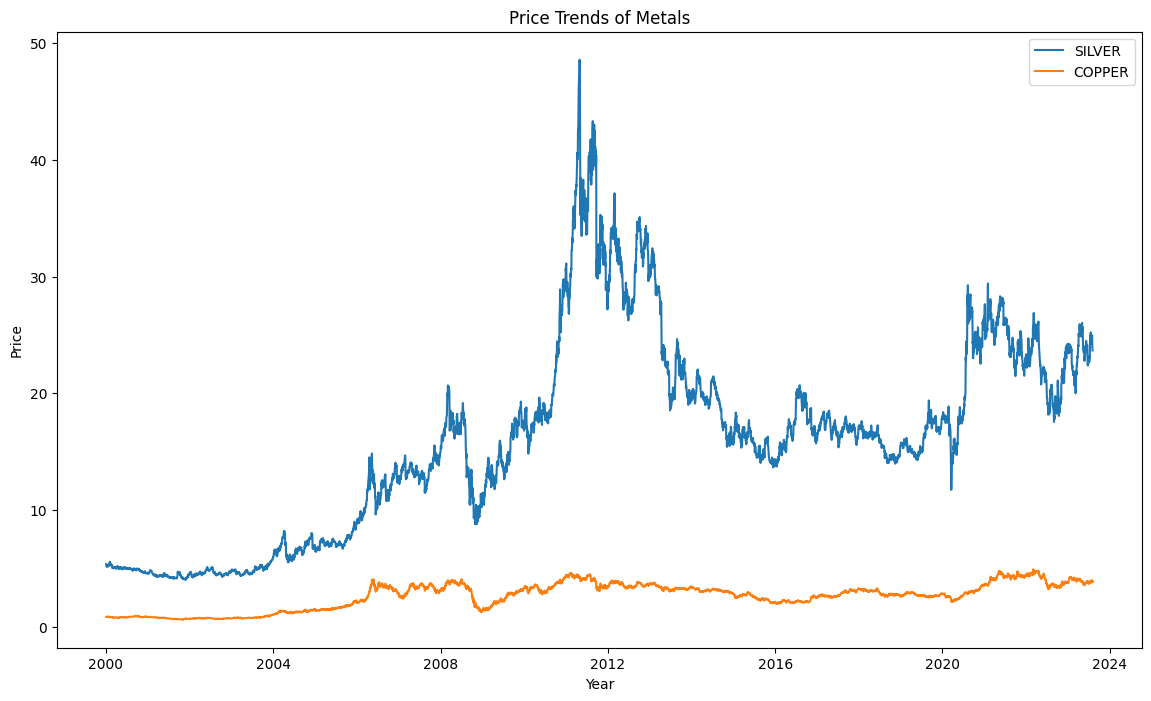

In [18]:
metals = ["SILVER", "COPPER"]
plt.figure(figsize=(14, 8))
for col in metals:
    plt.plot(df_clean['Date'], df_clean[col], label=col)
plt.title("Price Trends of Metals")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

In [19]:
# spike / fluctuations -> volatility
# sharp spike / rapid fluctuations -> [zinc, nickel]


## Seasonality & Volatility Analysis

In [20]:
yearly_avg = df_clean.groupby('Year').mean()

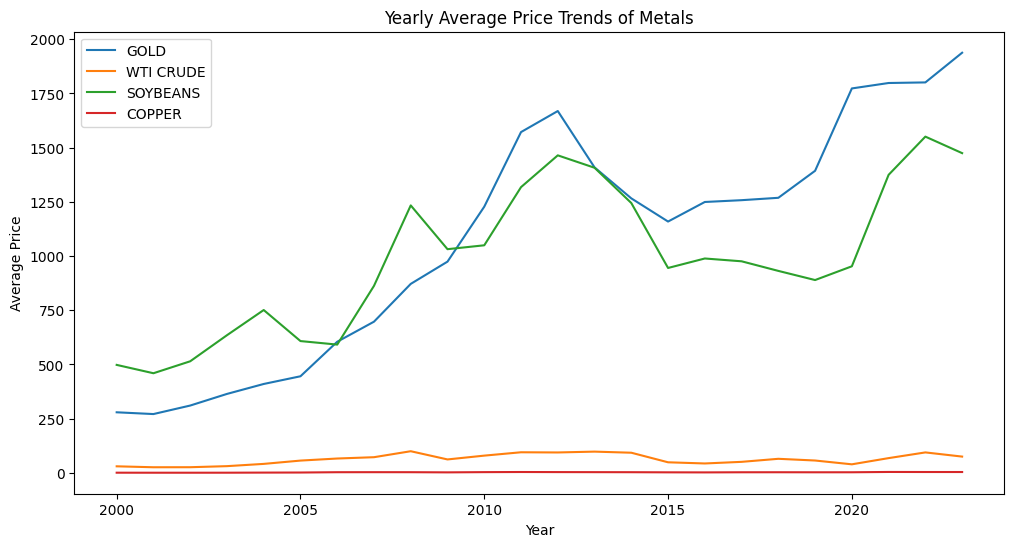

In [21]:
# Yearly average price trends of Metals
plt.figure(figsize=(12, 6))
for col in ["GOLD", "WTI CRUDE", "SOYBEANS", "COPPER"]:
    plt.plot(yearly_avg.index, yearly_avg[col], label=col)
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Yearly Average Price Trends of Metals")
plt.legend()
plt.show()

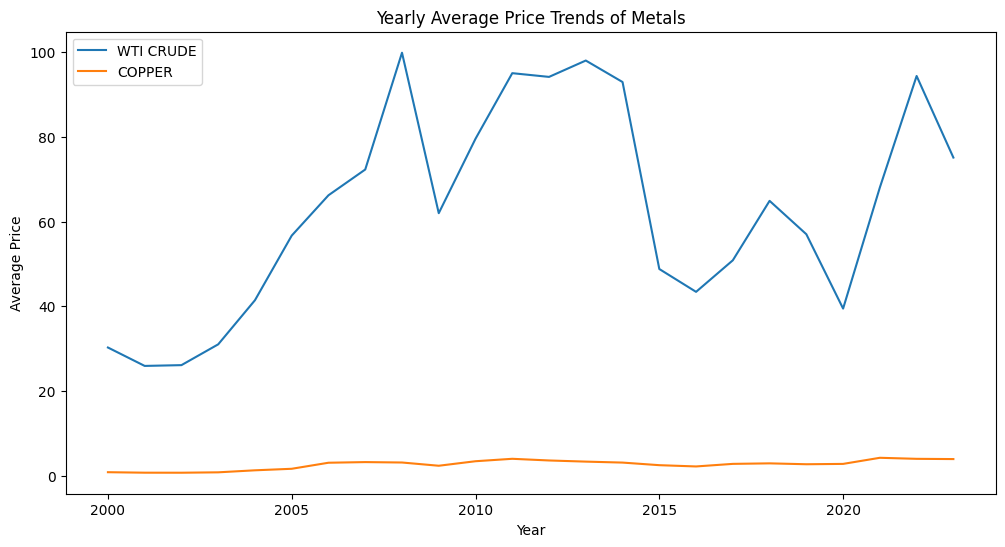

In [22]:
plt.figure(figsize=(12, 6))
for col in ["WTI CRUDE", "COPPER"]:
    plt.plot(yearly_avg.index, yearly_avg[col], label=col)
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Yearly Average Price Trends of Metals")
plt.legend()
plt.show()

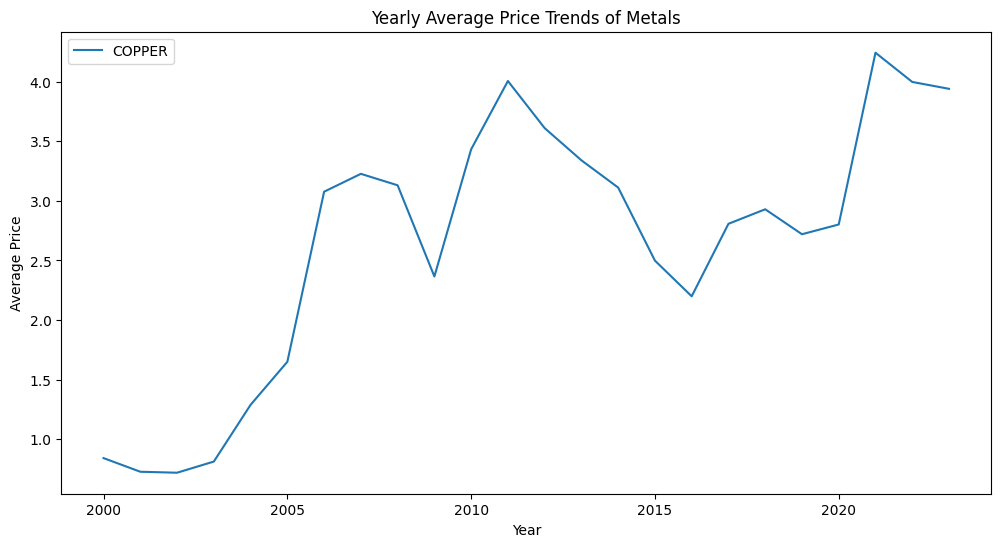

In [23]:
plt.figure(figsize=(12, 6))
for col in ["COPPER"]:
    plt.plot(yearly_avg.index, yearly_avg[col], label=col)
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Yearly Average Price Trends of Metals")
plt.legend()
plt.show()

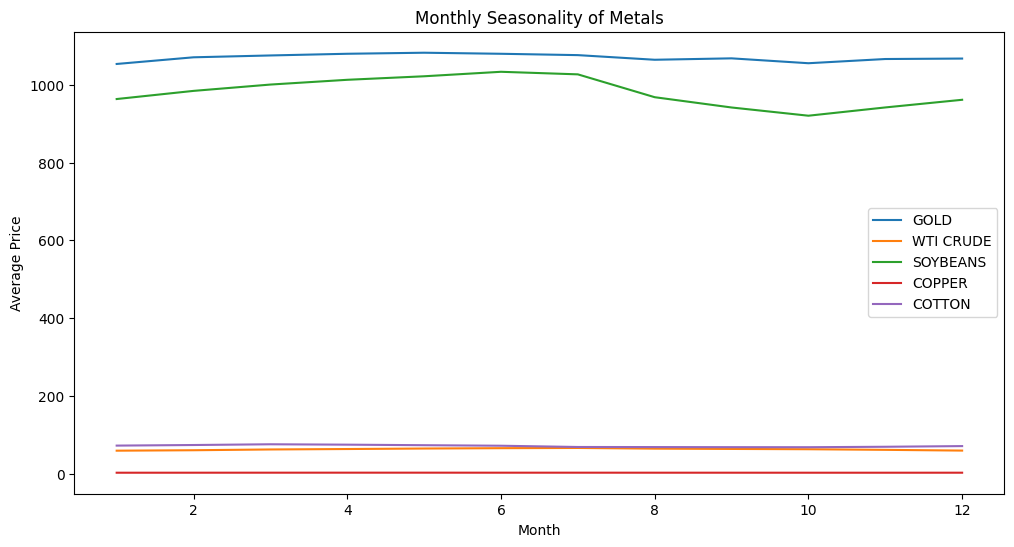

In [24]:
# Monthly Seasonility of Metals
# Are some months consistently higher/lower?

monthly_avg = df_clean.groupby('Month').mean()
plt.figure(figsize=(12, 6))
for col in ["GOLD", "WTI CRUDE", "SOYBEANS", "COPPER", "COTTON"]:
    plt.plot(monthly_avg.index, monthly_avg[col], label=col)
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.title("Monthly Seasonality of Metals")
plt.legend()
plt.show()

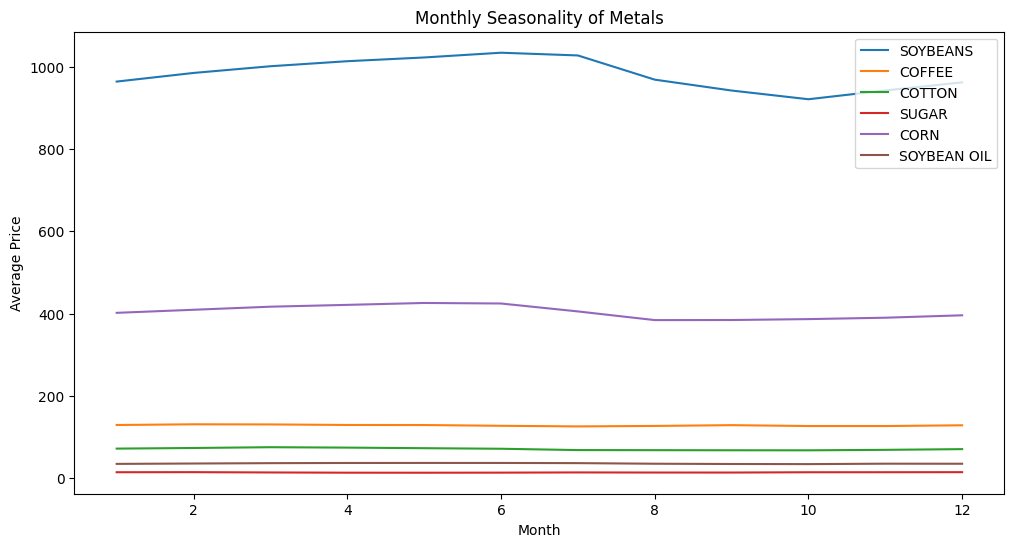

In [25]:
# Monthly Seasonility of Metals
# Are some months consistently higher/lower?

monthly_avg = df_clean.groupby('Month').mean()
plt.figure(figsize=(12, 6))
for col in ["SOYBEANS", "COFFEE", "COTTON", "SUGAR", "CORN", "SOYBEAN OIL"]:
    plt.plot(monthly_avg.index, monthly_avg[col], label=col)
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.title("Monthly Seasonality of Metals")
plt.legend()
plt.show()

In [29]:
# Volatility
# Standard deviation of daily returns as a measure of volatility to comapre how risky different commodities are.

returns = df_clean.set_index("Date").pct_change().dropna()

In [30]:
returns.std()

NATURAL GAS            0.036083
GOLD                   0.010798
WTI CRUDE              0.049825
BRENT CRUDE            0.023152
SOYBEANS               0.015370
CORN                   0.017947
COPPER                 0.016620
SILVER                 0.019228
LOW SULPHUR GAS OIL    0.022091
LIVE CATTLE            0.011377
SOYBEAN OIL            0.015504
ALUMINIUM              0.014060
SOYBEAN MEAL           0.018261
ZINC                   0.019931
ULS DIESEL             0.023436
NICKEL                 0.026091
WHEAT                  0.020178
SUGAR                  0.020480
GASOLINE               0.023003
COFFEE                 0.021130
LEAN HOGS              0.023323
HRW WHEAT              0.018508
COTTON                 0.018852
Year                   0.000031
Month                  0.096103
dtype: float64

In [31]:
volatility = returns.std().sort_values(ascending=False)
print(volatility)

Month                  0.096103
WTI CRUDE              0.049825
NATURAL GAS            0.036083
NICKEL                 0.026091
ULS DIESEL             0.023436
LEAN HOGS              0.023323
BRENT CRUDE            0.023152
GASOLINE               0.023003
LOW SULPHUR GAS OIL    0.022091
COFFEE                 0.021130
SUGAR                  0.020480
WHEAT                  0.020178
ZINC                   0.019931
SILVER                 0.019228
COTTON                 0.018852
HRW WHEAT              0.018508
SOYBEAN MEAL           0.018261
CORN                   0.017947
COPPER                 0.016620
SOYBEAN OIL            0.015504
SOYBEANS               0.015370
ALUMINIUM              0.014060
LIVE CATTLE            0.011377
GOLD                   0.010798
Year                   0.000031
dtype: float64


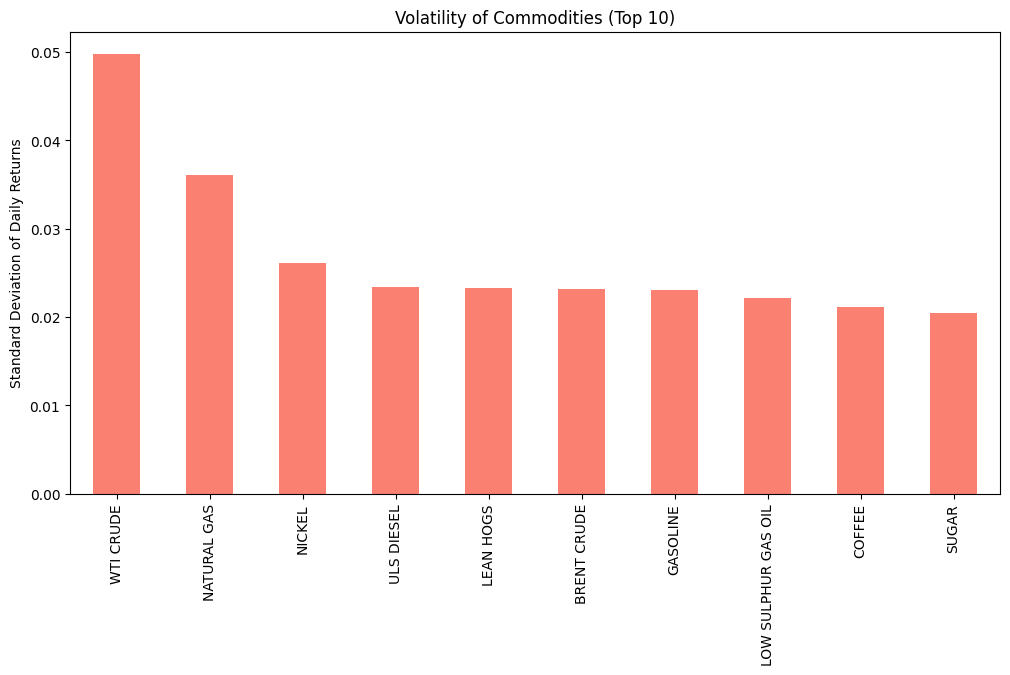

In [33]:
plt.figure(figsize=(12, 6))
volatility_new = volatility.drop(["Month", "Year"])
volatility_new.head(10).plot(kind='bar', color='salmon')
plt.title("Volatility of Commodities (Top 10)")
plt.ylabel("Standard Deviation of Daily Returns")
plt.show()